In [7]:
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt

import lifesim

This is how I get yields for spectral types, feel free to adapt to experiments, etc.

In [3]:
def get_yields(cat):
    yields = {}

    for type in np.unique(cat.stype):
        tcat = deepcopy(cat[cat.stype == type])
        tyield = []
        for nu in np.unique(tcat.nuniverse):
            tyield.append(np.logical_and.reduce((tcat.nuniverse == nu,
                                                 tcat.detected,
                                                 tcat.habitable)).sum())

        yields[type] = [float(np.mean(tyield)), float(np.std(tyield))]

    return yields

In [5]:
bus = lifesim.Bus()
bus.build_from_config('/Users/fdannert/Documents/projects/LIFEsim/working/development/experiment_yields/output/test_run_opt.yaml')
bus.data.import_catalog(input_path='/Users/fdannert/Documents/projects/LIFEsim/working/development/experiment_yields/output/test_run_opt_catalog.hdf5')

yields = get_yields(bus.data.catalog)

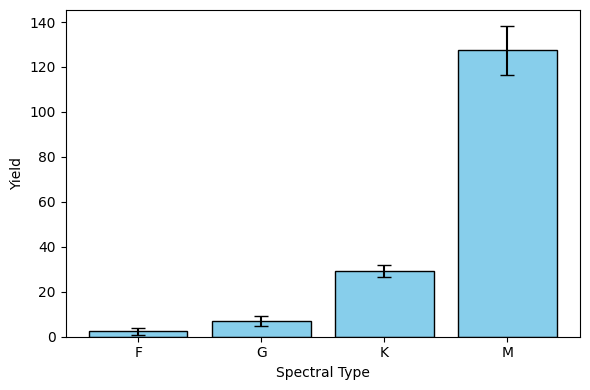

In [9]:
labels = list(yields.keys())
means = [yields[k][0] for k in labels]
stds = [yields[k][1] for k in labels]

plt.figure(figsize=(6,4))
plt.bar(labels, means, yerr=stds, capsize=5, color='skyblue', edgecolor='black')
plt.ylabel('Yield')
plt.xlabel('Spectral Type')
plt.tight_layout()
plt.show()